# LSTM-GAT with Static Graph

This notebook implements an LSTM-GAT model with **sparse attention masked by a static graph**.

The graph defines which stocks can attend to each other; attention learns
the importance weights within that structure.

**Architecture**: Shared LSTM per ticker → Sparse GAT (graph-masked attention) → Position output

## 1. Setup

In [1]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [2]:
import os
import sys

if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/repo'...
remote: Enumerating objects: 320, done.
remote: Counting objects: 100% (320/320), done.
remote: Compressing objects: 100% (175/175), done.
remote: Total 320 (delta 147), reused 311 (delta 138), pack-reused 0 (from 0)
Receiving objects: 100% (320/320), 10.49 MiB | 31.79 MiB/s, done.
Resolving deltas: 100% (147/147), done.
Working directory: /content/repo/4YP-main


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio,
    sortino_ratio,
    max_drawdown,
    annual_return,
    annual_volatility,
    calmar_ratio,
)

import random
random.seed(40)
np.random.seed(40)

import tensorflow as tf
tf.random.set_seed(40)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/features.csv')

Mounted at /content/drive


## 2. Configuration

In [5]:
# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023

VOL_TARGET = 0.15

# Graph Configuration
# Options: "cvx", "pearson", "straddle_pearson", "equity_pearson"
GRAPH_TYPE = "straddle_pearson"
ALPHA = 100    # CVX parameter (if using cvx)
BETA = 0.1     # CVX parameter (if using cvx)
TAU = 0.5      # Correlation threshold (if using pearson types)

# On-the-fly Pearson Configuration
USE_TRAINING_DATA_ONLY = True
NORMALIZE_ADJACENCY = True

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# GAT Hyperparameters
HIDDEN_LAYER_SIZE = 10
GAT_UNITS = 8
ATTN_HEADS = 2
DROPOUT_RATE = 0.5
LEARNING_RATE = 0.0005
MAX_GRADIENT_NORM = 0.01
NUM_GAT_LAYERS = 2
BATCH_SIZE = 32

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"\nModel: LSTM-GAT with Static Graph")
print(f"  Graph type: {GRAPH_TYPE}")
if GRAPH_TYPE == "cvx":
    print(f"  Alpha: {ALPHA}, Beta: {BETA}")
else:
    print(f"  Threshold: {TAU}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}")
print(f"  GAT layers: {NUM_GAT_LAYERS}")
print(f"  Dropout: {DROPOUT_RATE}")
print(f"  Learning rate: {LEARNING_RATE}")

Train: 2011-2017
Test:  2017-2023

Model: LSTM-GAT with Static Graph
  Graph type: straddle_pearson
  Threshold: 0.5
  GAT units: 8, heads: 2
  GAT layers: 2
  Dropout: 0.5
  Learning rate: 0.0005


## 3. Helper Functions

In [18]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))

    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Data Loading and Preparation

In [6]:
features_path = "/content/drive/MyDrive/features.csv"
#features_path = "data/straddle_features/features.csv"
df = pd.read_csv(features_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88


In [7]:
from gml.graph_model_inputs import GraphModelFeatures

features = GraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
)

print("Feature generator created.")

no lags


train _batch
After final stacking and culling:
inputs.shape: (57, 88, 20, 10)
outputs.shape: (57, 88, 20, 1)
active_entries.shape: (57, 88, 20, 1)
identifier.shape: (57, 88, 20, 1)
date.shape: (57, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (14, 88, 20, 10)
outputs.shape: (14, 88, 20, 1)
active_entries.shape: (14, 88, 20, 1)
identifier.shape: (14, 88, 20, 1)
date.shape: (14, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
Feature generator created.


In [8]:
train_data = features.train
valid_data = features.valid
test_data = features.test_sliding

print("Training data:")
print(f"  inputs: {train_data['inputs'].shape}")
print(f"  outputs: {train_data['outputs'].shape}")
print(f"\nValidation data:")
print(f"  inputs: {valid_data['inputs'].shape}")
print(f"  outputs: {valid_data['outputs'].shape}")
print(f"\nTest data:")
print(f"  inputs: {test_data['inputs'].shape}")
print(f"  outputs: {test_data['outputs'].shape}")

Training data:
  inputs: (57, 88, 20, 10)
  outputs: (57, 88, 20, 1)

Validation data:
  inputs: (14, 88, 20, 10)
  outputs: (14, 88, 20, 1)

Test data:
  inputs: (1400, 88, 20, 10)
  outputs: (1400, 88, 20, 1)


## 5. Load Adjacency Matrix

In [9]:
from gml.straddle_graph import load_or_compute_adjacency
from settings.default import ALL_TICKERS

adjacency = load_or_compute_adjacency(
    graph_type=GRAPH_TYPE,
    df=df if GRAPH_TYPE == "straddle_pearson" else None,
    alpha=ALPHA,
    beta=BETA,
    tau=TAU,
    tickers=ALL_TICKERS,
    train_end_year=TEST_START if (GRAPH_TYPE in ["straddle_pearson", "equity_pearson"] and USE_TRAINING_DATA_ONLY) else None,
    normalize=NORMALIZE_ADJACENCY if GRAPH_TYPE in ["straddle_pearson", "equity_pearson"] else False,
)

print(f"\nAdjacency matrix shape: {adjacency.shape}")
print(f"Non-zero entries: {(adjacency != 0).sum()}")
print(f"Value range: [{adjacency.min():.4f}, {adjacency.max():.4f}]")

Using data before 2017 for correlation computation
Computing correlation from 1560 days of straddle returns
Date range: 2010-07-01 00:00:00 to 2016-12-30 00:00:00
Edges (before normalization): 14
Density: 0.0036
Applied symmetric normalization

Adjacency matrix shape: (88, 88)
Non-zero entries: 116
Value range: [0.0000, 1.0000]


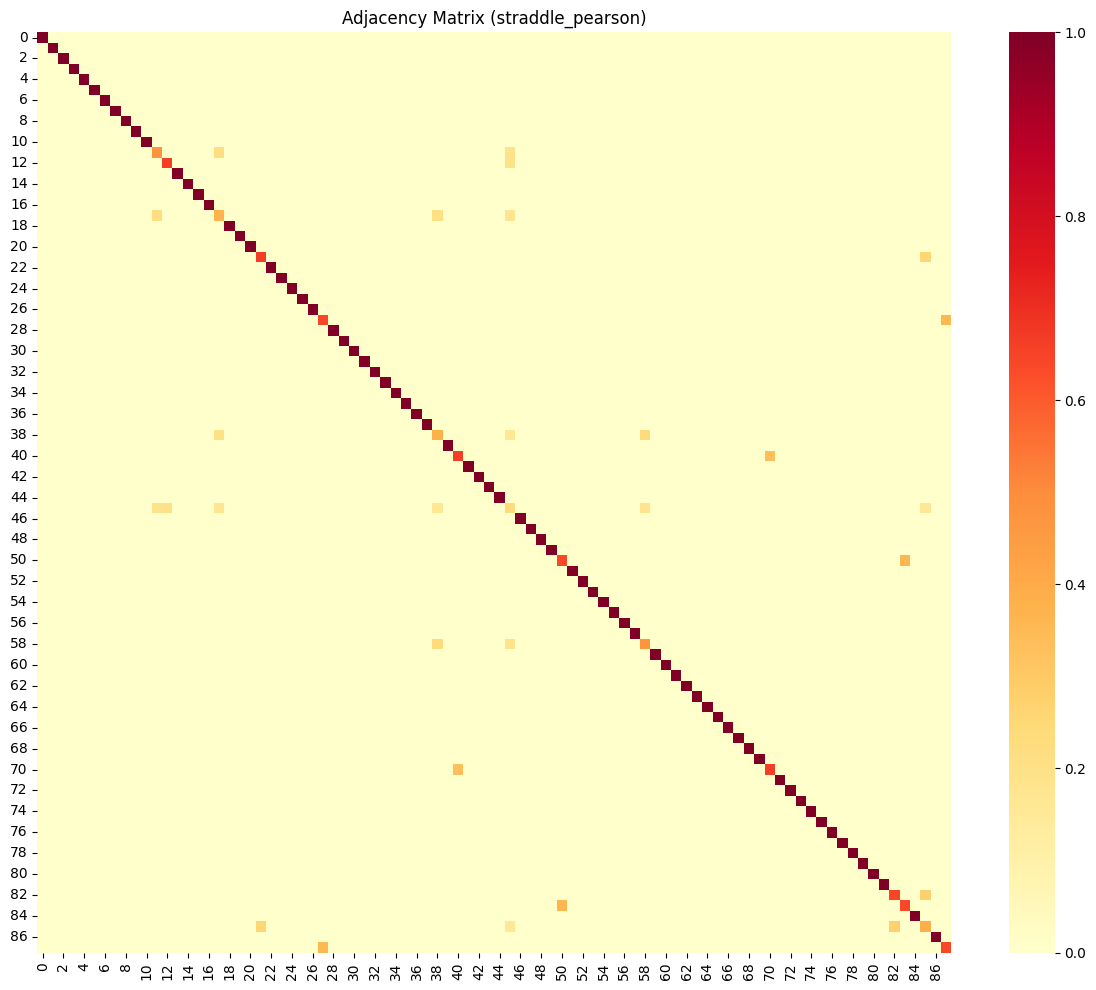

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(adjacency, cmap='YlOrRd')
plt.title(f'Adjacency Matrix ({GRAPH_TYPE})')
plt.tight_layout()
plt.show()

## 6. Model Definition

In [11]:
from gml.graph_model_gat_v2 import build_lstm_gat_sparse_model

num_tickers = train_data['inputs'].shape[1]
time_steps = train_data['inputs'].shape[2]
input_size = train_data['inputs'].shape[3]

print(f"Building LSTM-GAT Sparse model:")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps}")
print(f"  input_size: {input_size}")
print(f"  Graph type: {GRAPH_TYPE}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}")

model = build_lstm_gat_sparse_model(
    num_tickers=num_tickers,
    time_steps=time_steps,
    input_size=input_size,
    adjacency=adjacency,
    hidden_layer_size=HIDDEN_LAYER_SIZE,
    gat_units=GAT_UNITS,
    attn_heads=ATTN_HEADS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    max_gradient_norm=MAX_GRADIENT_NORM,
    num_gat_layers=NUM_GAT_LAYERS,
)

# model.summary()

Building LSTM-GAT Sparse model:
  num_tickers: 88
  time_steps: 20
  input_size: 10
  Graph type: straddle_pearson
  GAT units: 8, heads: 2


## 7. Training

In [12]:
X_train = train_data['inputs']
y_train = train_data['outputs']
w_train = train_data['active_entries']

X_valid = valid_data['inputs']
y_valid = valid_data['outputs']
w_valid = valid_data['active_entries']

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_valid.shape[0]}")

Training samples: 57
Validation samples: 14


In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("="*60)
print(f"Training LSTM-GAT with Static Graph ({GRAPH_TYPE})")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print("="*60)

history = model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    validation_data=(X_valid, y_valid, w_valid),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Training LSTM-GAT with Static Graph (straddle_pearson)
  GAT units: 8, heads: 2, layers: 2
Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 246s 55s/step - loss: -0.5365 - val_loss: -0.8564
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step - loss: -0.5479 - val_loss: -0.8541
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - loss: -0.5918 - val_loss: -0.8570
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - loss: -0.5760 - val_loss: -0.8572
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step - loss: -0.6271 - val_loss: -0.8582
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - loss: -0.5902 - val_loss: -0.8620
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - loss: -0.6046 - val_loss: -0.8637
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step - loss: -0.6494 - val_loss: -0.8668
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step - loss: -0.5803 - val_loss: -0.8703
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - loss: -0.6331 - val_loss: -0.8725
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 

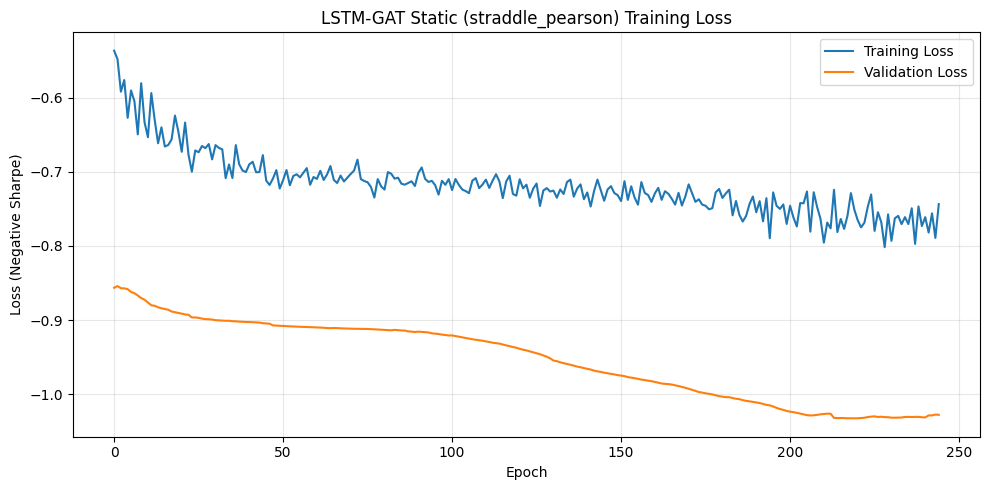

Epochs trained: 245
Best val loss: -1.0325


In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Sharpe)')
plt.title(f'LSTM-GAT Static ({GRAPH_TYPE}) Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")

## 8. Evaluation

In [15]:
X_test = test_data['inputs']
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"Test outputs shape: {test_data['outputs'].shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step 
Predictions shape: (1400, 88, 20, 1)
Test outputs shape: (1400, 88, 20, 1)


In [16]:
positions = predictions[:, :, -1, 0].reshape(-1)
returns = test_data['outputs'][:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

dates = test_data['date'][:, :, -1, 0].reshape(-1)
identifiers = test_data['identifier'][:, :, -1, 0].reshape(-1)

results_df = pd.DataFrame({
    'time': dates,
    'identifier': identifiers,
    'position': positions,
    'returns': returns,
    'captured_returns': captured_returns,
})

results_df['time'] = pd.to_datetime(results_df['time'])
results_df = results_df[results_df['identifier'] != '0']

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,-0.671507,-0.009874,0.006631
1,2017-01-03,ABT,-0.792242,-0.002442,0.001935
2,2017-01-03,ACN,-0.504624,-0.008236,0.004156
3,2017-01-03,ADBE,-0.608372,-0.010764,0.006548
4,2017-01-03,AIG,-0.660644,-0.003832,0.002531


In [19]:
daily_returns = calc_daily_returns(results_df)

print("\n" + "="*60)
print(f"LSTM-GAT Static Graph Results ({GRAPH_TYPE})")
print("="*60)

metrics_raw = calc_metrics(daily_returns, f"LSTM-GAT Static ({GRAPH_TYPE})")
display_metrics(metrics_raw)

print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, f"LSTM-GAT Static ({GRAPH_TYPE})", VOL_TARGET)
display_metrics(metrics_norm)

print("\nYearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe_val in yearly_sharpes.items():
    print(f"  {year}: {sharpe_val:.4f}")


LSTM-GAT Static Graph Results (straddle_pearson)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GAT Static (straddle_pearson),4.85%,4.67%,1.038,1.404,7.33%,0.662,60.29%,0.802



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GAT Static (straddle_pearson) (Vol-Norm),15.52%,15.00%,1.038,1.404,22.11%,0.702,60.29%,0.802



Yearly Sharpe Ratios:
  2017: 3.6745
  2018: -0.4038
  2019: 2.5221
  2020: 0.4710
  2021: 1.4219
  2022: 0.5532


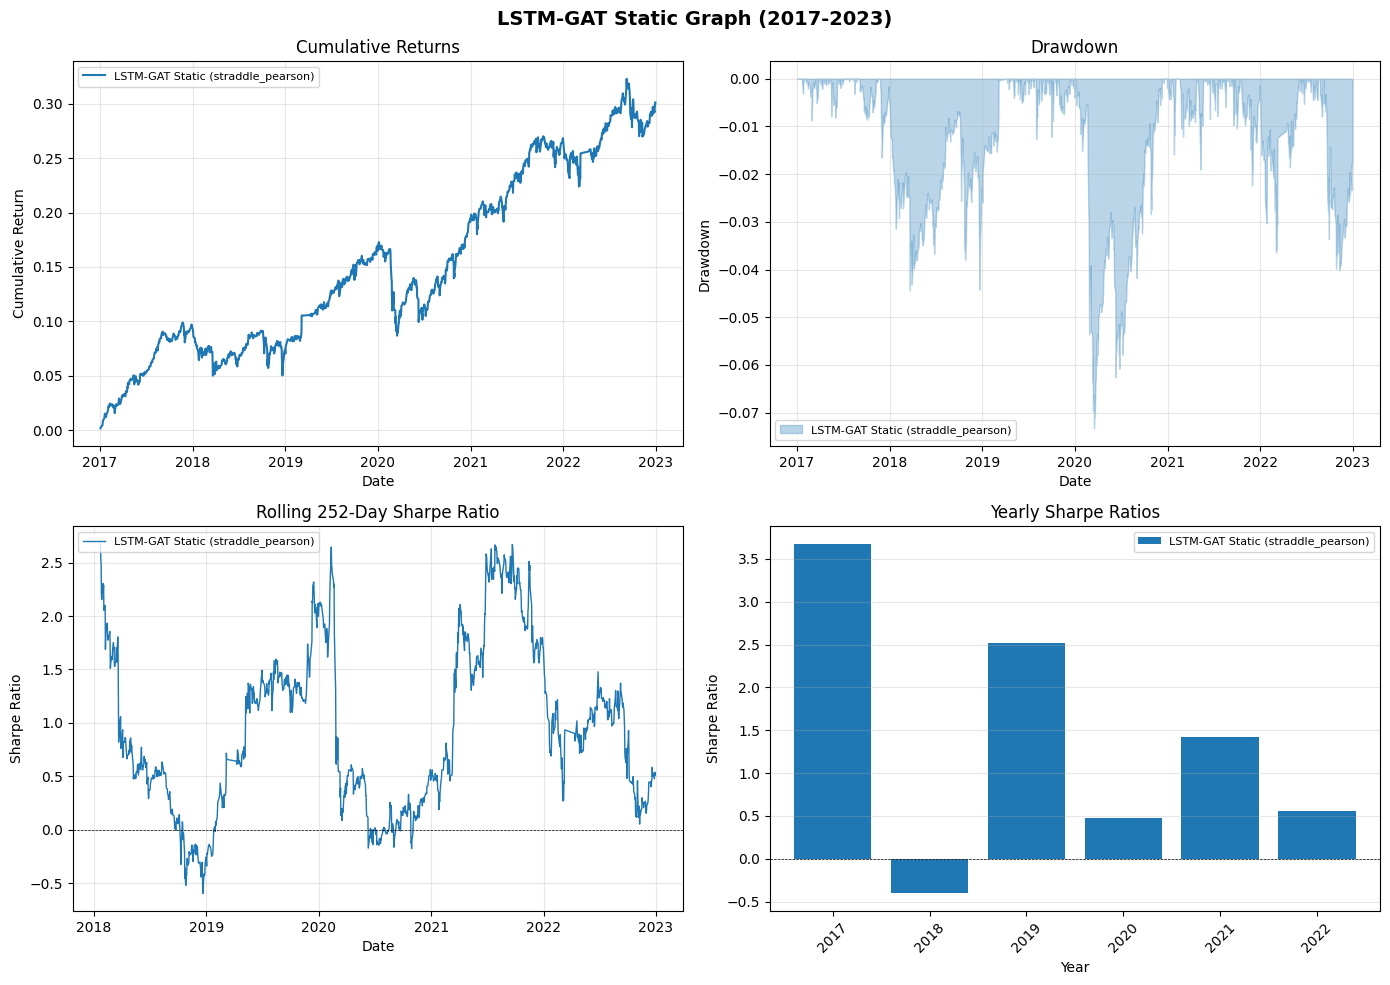

In [20]:
all_daily_returns = {f'LSTM-GAT Static ({GRAPH_TYPE})': daily_returns}
plot_results(all_daily_returns, f"LSTM-GAT Static Graph ({TEST_START}-{TEST_END})")

## 9. Position Analysis

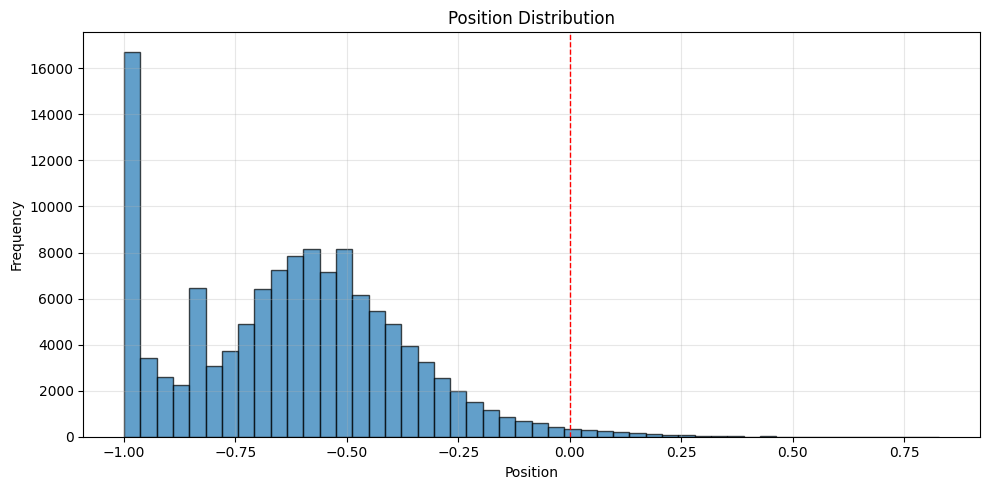

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(results_df['position'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Frequency')
plt.title('Position Distribution')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Interactive Graph Visualization

Visualize how the GAT's learned attention graph changes over time.
Drag the slider to see the network at different dates, with rolling Sharpe below.

In [ ]:
# Extract attention weights from trained model
from gml.graph_model_gat_v2 import extract_attention_weights

print("Extracting attention weights for all test samples...")
X_test = test_data['inputs']
all_attention = extract_attention_weights(model, X_test, gat_layer_name="sparse_gat_0")
print(f"Attention shape: {all_attention.shape}")  # (num_samples, num_heads, 88, 88)

# Average across heads to get a single graph per sample
all_graphs = all_attention.mean(axis=1)  # (num_samples, 88, 88)
print(f"Graphs shape: {all_graphs.shape}")

In [ ]:
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
from settings.default import ALL_TICKERS, BBG_SECTORS

# Sector colors
SECTOR_COLORS = {
    "Information Technology": "#1f77b4",
    "Healthcare": "#2ca02c",
    "Financials": "#ff7f0e",
    "Consumer Discretionary": "#d62728",
    "Consumer Staples": "#9467bd",
    "Industrials": "#8c564b",
    "Communication Services": "#e377c2",
    "Energy": "#7f7f7f",
    "Utilities": "#bcbd22",
    "Real Estate": "#17becf",
}

# Build a reference graph for fixed layout
tickers = sorted(ALL_TICKERS)
G_ref = nx.Graph()
for t in tickers:
    G_ref.add_node(t, sector=BBG_SECTORS.get(t, "Unknown"))

# Fixed node positions (computed once so nodes don't jump)
fixed_pos = nx.spring_layout(G_ref, k=2.5, iterations=100, seed=42)
node_colors = [SECTOR_COLORS.get(BBG_SECTORS.get(t, "Unknown"), "#cccccc") for t in tickers]

# Compute rolling Sharpe for the bottom panel
rolling_sharpe = daily_returns.rolling(252).mean() / daily_returns.rolling(252).std() * np.sqrt(252)

# Get test dates (one per window)
test_dates_arr = pd.to_datetime(test_data['date'][:, 0, -1, 0])

print(f"Ready: {len(all_graphs)} graphs, {len(test_dates_arr)} dates")

In [ ]:
# Interactive graph visualization with rolling Sharpe
EDGE_THRESHOLD = 0.05  # Minimum attention/correlation weight to show as edge

output_widget = widgets.Output()

def update_graph(window_idx):
    with output_widget:
        clear_output(wait=True)
        
        fig, (ax_graph, ax_sharpe) = plt.subplots(
            2, 1, figsize=(14, 16),
            gridspec_kw={'height_ratios': [3, 1]}
        )
        
        # --- Top: Network graph ---
        adj = all_graphs[window_idx]
        date_str = str(test_dates_arr[window_idx].date())
        
        # Build graph for this window
        G = nx.Graph()
        for t in tickers:
            G.add_node(t)
        
        n = len(tickers)
        for i in range(n):
            for j in range(i + 1, n):
                w = (adj[i, j] + adj[j, i]) / 2  # symmetrize
                if abs(w) > EDGE_THRESHOLD:
                    G.add_edge(tickers[i], tickers[j], weight=w)
        
        # Draw edges
        edges = G.edges(data=True)
        if len(edges) > 0:
            weights = [d['weight'] for _, _, d in edges]
            max_w = max(abs(w) for w in weights) if weights else 1.0
            for (u, v, d) in edges:
                w = d['weight']
                width = 2.0 * abs(w) / max_w
                alpha = 0.3 + 0.7 * abs(w) / max_w
                x = [fixed_pos[u][0], fixed_pos[v][0]]
                y = [fixed_pos[u][1], fixed_pos[v][1]]
                ax_graph.plot(x, y, color='gray', linewidth=width, alpha=alpha, zorder=1)
        
        # Draw nodes
        nx.draw_networkx_nodes(G, fixed_pos, node_color=node_colors,
                               node_size=600, alpha=0.9, ax=ax_graph)
        nx.draw_networkx_labels(G, fixed_pos, font_size=6, font_weight='bold', ax=ax_graph)
        
        num_edges = G.number_of_edges()
        ax_graph.set_title(f"Graph at {date_str}  |  {num_edges} edges (threshold={EDGE_THRESHOLD})",
                          fontsize=14, fontweight='bold')
        ax_graph.axis('off')
        
        # --- Bottom: Rolling Sharpe with date marker ---
        ax_sharpe.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color='blue')
        ax_sharpe.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax_sharpe.axvline(x=test_dates_arr[window_idx], color='red', linewidth=2, alpha=0.8)
        ax_sharpe.set_title('Rolling 252-Day Sharpe Ratio', fontsize=12)
        ax_sharpe.set_xlabel('Date')
        ax_sharpe.set_ylabel('Sharpe')
        ax_sharpe.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

slider = widgets.IntSlider(
    min=0, max=len(all_graphs) - 1, step=1, value=0,
    description='Window:',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

widgets.interactive(update_graph, window_idx=slider)
display(slider, output_widget)
update_graph(0)  # Show initial frame

## 11. Save Results

In [22]:
if GRAPH_TYPE == "cvx":
    results_dir = f"results/lstm_gat_static_cvx_{ALPHA}_{BETA}/{TEST_START}-{TEST_END}"
elif GRAPH_TYPE == "pearson":
    results_dir = f"results/lstm_gat_static_pearson_{TAU}/{TEST_START}-{TEST_END}"
elif GRAPH_TYPE == "straddle_pearson":
    norm_str = "norm" if NORMALIZE_ADJACENCY else "unnorm"
    train_str = "trainonly" if USE_TRAINING_DATA_ONLY else "alldata"
    results_dir = f"results/lstm_gat_static_straddle_{TAU}_{norm_str}_{train_str}/{TEST_START}-{TEST_END}"
elif GRAPH_TYPE == "equity_pearson":
    norm_str = "norm" if NORMALIZE_ADJACENCY else "unnorm"
    train_str = "trainonly" if USE_TRAINING_DATA_ONLY else "alldata"
    results_dir = f"results/lstm_gat_static_equity_{TAU}_{norm_str}_{train_str}/{TEST_START}-{TEST_END}"

os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, "captured_returns_sw.csv"), index=False)

metrics_df = pd.DataFrame([metrics_raw])
metrics_df.to_csv(os.path.join(results_dir, "metrics_raw.csv"), index=False)

metrics_norm_df = pd.DataFrame([metrics_norm])
metrics_norm_df.to_csv(os.path.join(results_dir, "metrics_vol_normalized.csv"), index=False)

yearly_df = pd.DataFrame(yearly_sharpes.items(), columns=['Year', 'Sharpe'])
yearly_df.to_csv(os.path.join(results_dir, "yearly_sharpes.csv"), index=False)

print(f"Results saved to: {results_dir}")

Results saved to: results/lstm_gat_static_straddle_0.5_norm_trainonly/2017-2023


## 12. Summary

In [23]:
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nModel: LSTM-GAT with Static Graph")
print(f"  Graph type: {GRAPH_TYPE}")
if GRAPH_TYPE == "cvx":
    print(f"  Alpha: {ALPHA}, Beta: {BETA}")
else:
    print(f"  Threshold: {TAU}")
print(f"\nGAT Hyperparameters:")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}")
print(f"  GAT layers: {NUM_GAT_LAYERS}")
print(f"  Dropout: {DROPOUT_RATE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"\nTraining Period: {TRAIN_START} - {TEST_START}")
print(f"Test Period:     {TEST_START} - {TEST_END}")
print(f"\nPerformance (Raw):")
print(f"  Sharpe Ratio: {metrics_raw['Sharpe']:.3f}")
print(f"  Annual Return: {metrics_raw['E[Ret.]']:.2%}")
print(f"  Annual Volatility: {metrics_raw['Vol.']:.2%}")
print(f"  Sortino Ratio: {metrics_raw['Sortino']:.3f}")
print(f"  Max Drawdown: {metrics_raw['Max DD']:.2%}")

EXPERIMENT SUMMARY

Model: LSTM-GAT with Static Graph
  Graph type: straddle_pearson
  Threshold: 0.5

GAT Hyperparameters:
  LSTM hidden: 10
  GAT units: 8, heads: 2
  GAT layers: 2
  Dropout: 0.5
  Learning rate: 0.0005

Training Period: 2011 - 2017
Test Period:     2017 - 2023

Performance (Raw):
  Sharpe Ratio: 1.038
  Annual Return: 4.85%
  Annual Volatility: 4.67%
  Sortino Ratio: 1.404
  Max Drawdown: 7.33%
